# Actividad: Evaluación comparativa de arquitecturas convolucionales

Para este notebook se te solicita construir, entrenar y analizar modelos CNN para clasificar imágenes mediante el dataset **CIFAR-10** (10 clases: avión, automóvil, pájaro, gato, ciervo, perro, rana, caballo, barco, camión).

**Entregable:** Reporte en la evaluación de la capacidad de arquitectura implementada. Se construyen 2 arquitecturas propias finalizando con la implementación de MobileNetV2 mediante transfer learning.


TensorFlow : 2.15.1
NumPy      : 1.26.4

X_train: (50000, 32, 32, 3)  |  X_test: (10000, 32, 32, 3)


C:\Users\sebas\AppData\Local\Temp\ipykernel_19896\2566096346.py:34: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.set_title(CLASES[int(y_train[i])])


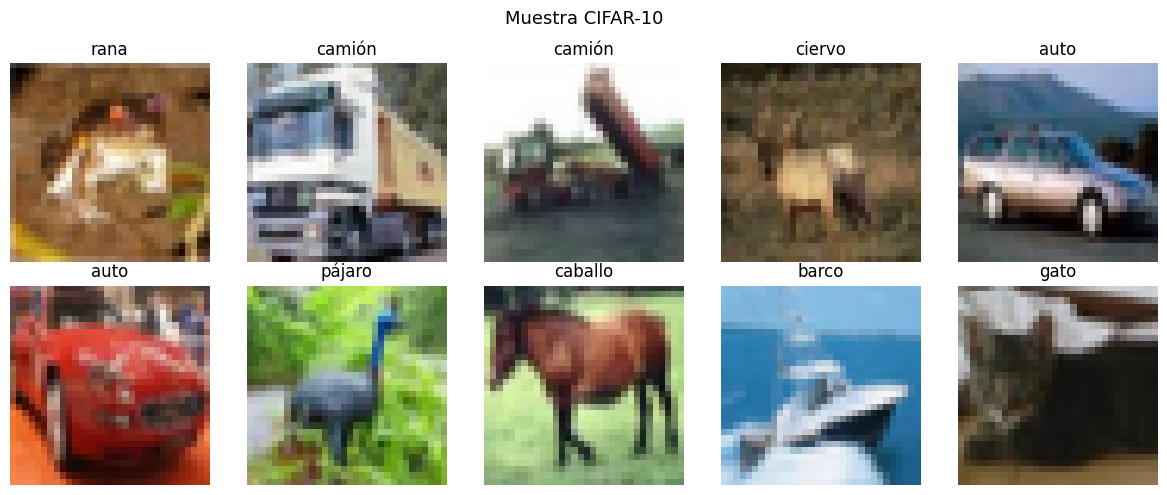

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

print(f'TensorFlow : {tf.__version__}')
print(f'NumPy      : {np.__version__}')

(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

y_train_oh = keras.utils.to_categorical(y_train, 10)
y_test_oh  = keras.utils.to_categorical(y_test,  10)

CLASES = ['avión','auto','pájaro','gato','ciervo',
          'perro','rana','caballo','barco','camión']

print(f'\nX_train: {X_train.shape}  |  X_test: {X_test.shape}')

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i])
    ax.set_title(CLASES[int(y_train[i])])
    ax.axis('off')
plt.suptitle('Muestra CIFAR-10', fontsize=13)
plt.tight_layout()
plt.show()

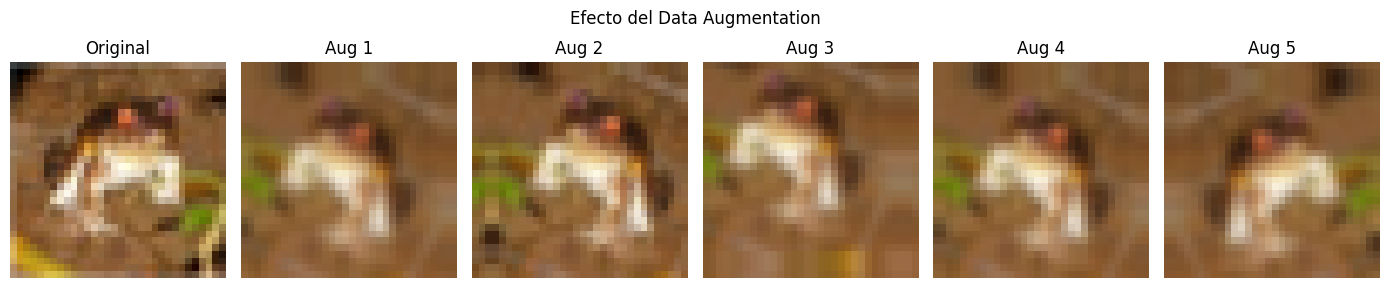

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
], name='data_augmentation')

sample = X_train[:1]
fig, axes = plt.subplots(1, 6, figsize=(14, 3))
axes[0].imshow(sample[0]); axes[0].set_title('Original'); axes[0].axis('off')
for i in range(1, 6):
    aug = data_augmentation(sample, training=True)[0].numpy()
    axes[i].imshow(np.clip(aug, 0, 1))
    axes[i].set_title(f'Aug {i}'); axes[i].axis('off')
plt.suptitle('Efecto del Data Augmentation', fontsize=12)
plt.tight_layout()
plt.show()

## Definición de modelos

In [ ]:
N_CLASES   = 10
INPUT_SHAPE = (32, 32, 3)

def construir_cnn1():
    inp = layers.Input(shape=INPUT_SHAPE)
    x = data_augmentation(inp)

    # Bloque 1
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    # Bloque 2
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    # Bloque 3
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)

    # Clasificador
    x = layers.Dense(128, activation='relu')(x)
    out = layers.Dense(N_CLASES, activation='softmax')(x)

    return models.Model(inp, out, name='CNN1_sencilla')

cnn1 = construir_cnn1()
cnn1.summary()

def construir_cnn2():
    reg = keras.regularizers.l2(1e-4)
    inp = layers.Input(shape=INPUT_SHAPE)
    x = data_augmentation(inp)

    # Bloque 1 — doble conv
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(x)
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.2)(x)

    # Bloque 2 — doble conv
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.3)(x)

    # Bloque 3 — triple conv
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)

    # Clasificador con L2
    x = layers.Dense(256, activation='relu', kernel_regularizer=reg)(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(N_CLASES, activation='softmax')(x)

    return models.Model(inp, out, name='CNN2_doble_bloque')

cnn2 = construir_cnn2()
cnn2.summary()

def construir_tl():
    inp = layers.Input(shape=INPUT_SHAPE)
    x = data_augmentation(inp)
    x = layers.Resizing(96, 96)(x)
    x = keras.applications.mobilenet_v2.preprocess_input(
            x * 255.0)

    base = MobileNetV2(input_shape=(96, 96, 3),
                       include_top=False,
                       weights='imagenet')
    base.trainable = False

    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    out = layers.Dense(N_CLASES, activation='softmax')(x)

    return models.Model(inp, out, name='TL_MobileNetV2')

cnn3 = construir_tl()
cnn3.summary()


Model: "CNN1_sencilla"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 32, 32, 3)]       0         
                                                                 
 data_augmentation (Sequent  (None, 32, 32, 3)         0         
 ial)                                                            
                                                                 
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 batch_normalization (Batch  (None, 32, 32, 32)        128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 16, 16, 32)        0         
 D)                                                              
                                                    

## Entrenamiento de modelos

In [4]:
EPOCHS     = 30
BATCH_SIZE = 64

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=5, restore_best_weights=True
)

# ── CNN 1 ───────────────────────────────────────────────────────────────────
cnn1.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print('Entrenando CNN1...')
hist1 = cnn1.fit(
    X_train, y_train_oh,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test_oh),
    callbacks=[early_stop], verbose=1
)

# ── CNN 2 ───────────────────────────────────────────────────────────────────
cnn2.compile(
    optimizer=keras.optimizers.Adam(5e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print('\nEntrenando CNN2...')
hist2 = cnn2.fit(
    X_train, y_train_oh,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test_oh),
    callbacks=[early_stop], verbose=1
)

# ── Transfer Learning ────────────────────────────────────────────────────────
cnn3.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print('\nEntrenando MobileNetV2 (transfer learning)...')
hist3 = cnn3.fit(
    X_train, y_train_oh,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test_oh),
    callbacks=[early_stop], verbose=1
)

# ── Resumen de resultados ────────────────────────────────────────────────────
print('\n── Resultados en test ──────────────────────────────────────')
for nombre, modelo in [('CNN1 sencilla', cnn1), ('CNN2 doble bloque', cnn2), ('TL MobileNetV2', cnn3)]:
    loss, acc = modelo.evaluate(X_test, y_test_oh, verbose=0)
    print(f'{nombre:22s}  →  loss={loss:.4f}  acc={acc:.4f}')

Entrenando CNN1...
Epoch 1/30


782/782 [==============================] - 27s 31ms/step - loss: 1.6567 - accuracy: 0.3931 - val_loss: 1.6251 - val_accuracy: 0.4256
Epoch 2/30
782/782 [==============================] - 24s 31ms/step - loss: 1.4255 - accuracy: 0.4823 - val_loss: 1.2187 - val_accuracy: 0.5586
Epoch 3/30
782/782 [==============================] - 26s 33ms/step - loss: 1.3406 - accuracy: 0.5163 - val_loss: 1.1824 - val_accuracy: 0.5742
Epoch 4/30
782/782 [==============================] - 25s 32ms/step - loss: 1.2887 - accuracy: 0.5356 - val_loss: 1.3344 - val_accuracy: 0.5592
Epoch 5/30
782/782 [==============================] - 25s 32ms/step - loss: 1.2563 - accuracy: 0.5524 - val_loss: 1.2168 - val_accuracy: 0.5743
Epoch 6/30
782/782 [==============================] - 25s 31ms/step - loss: 1.2205 - accuracy: 0.5637 - val_loss: 1.4100 - val_accuracy: 0.5329
Epoch 7/30
782/782 [==============================] - 23s 30ms/step - loss: 1.1995 - accuracy: 0.5727 - val_loss: 1

## Estadística y gráficos

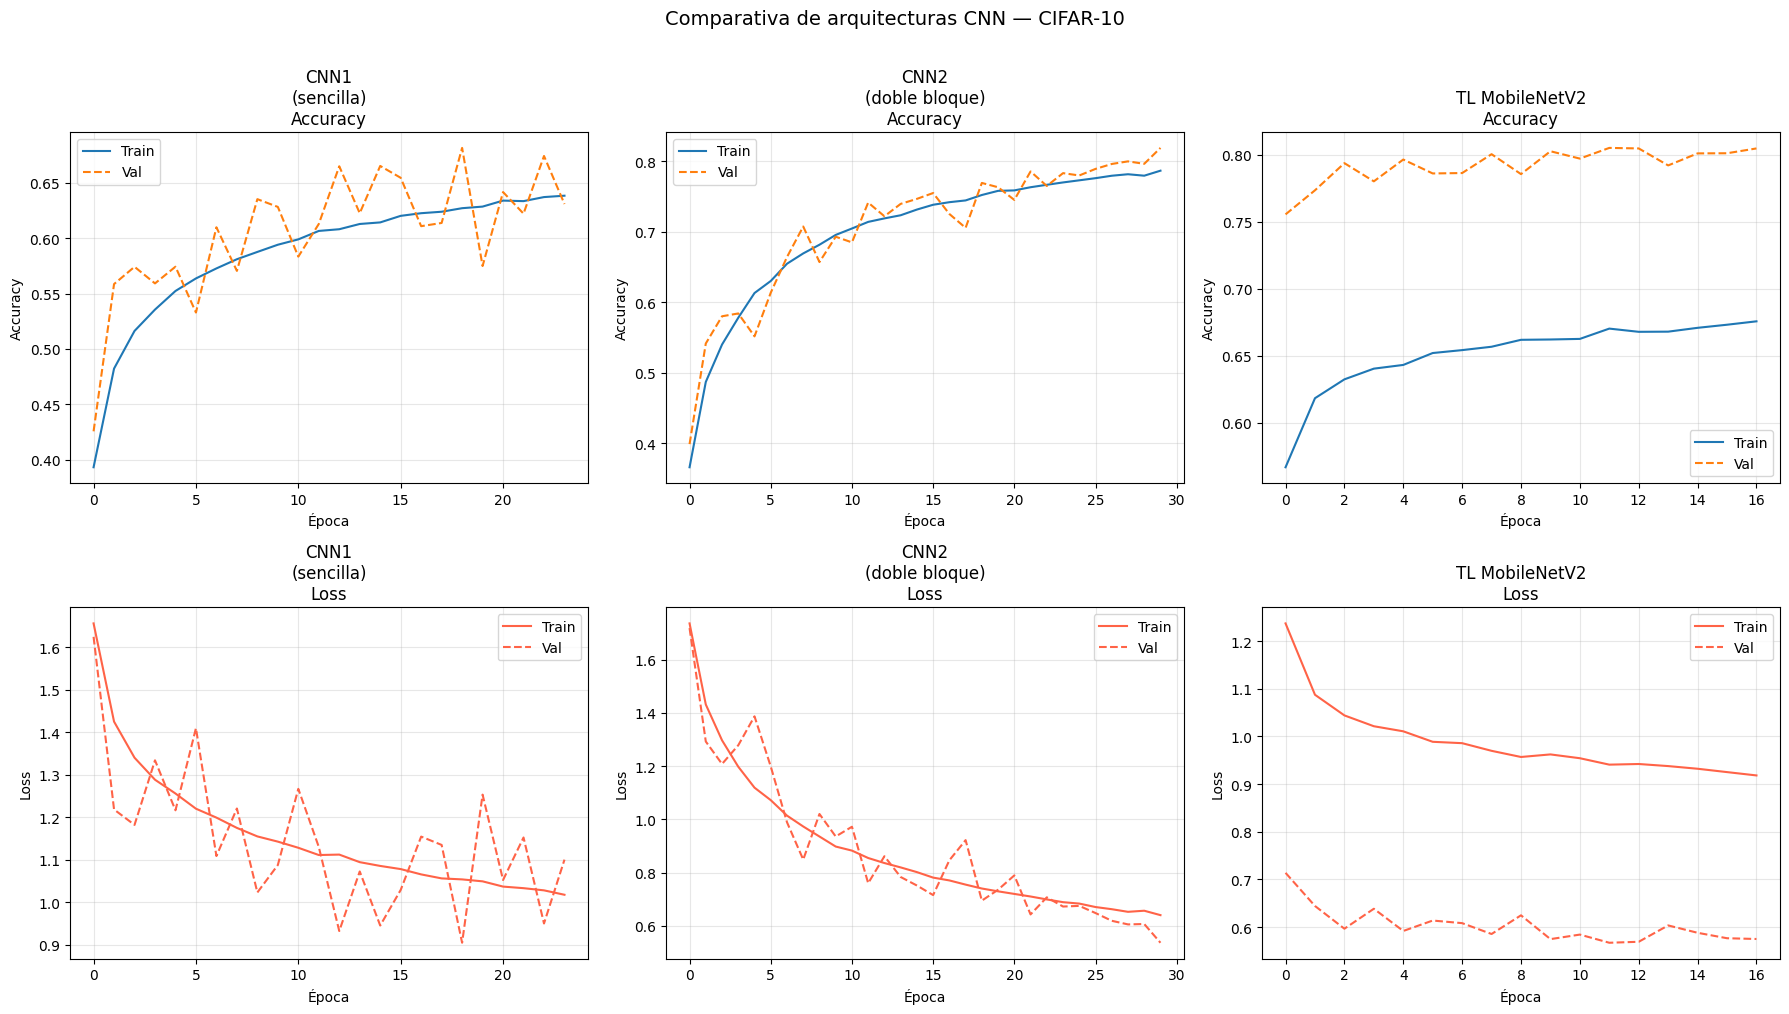

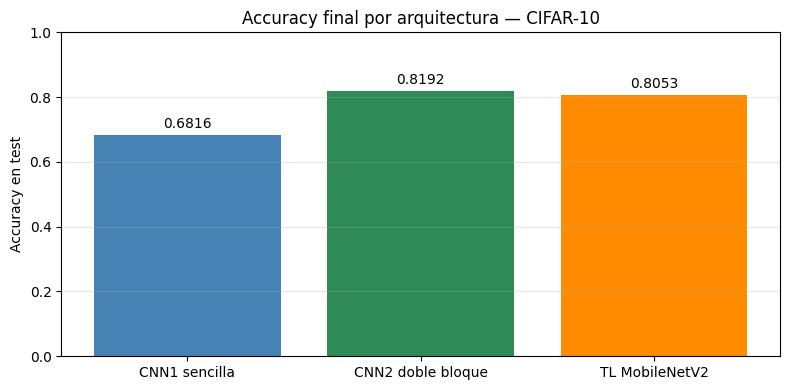

In [5]:
historiales = [
    (hist1, 'CNN1\n(sencilla)'),
    (hist2, 'CNN2\n(doble bloque)'),
    (hist3, 'TL MobileNetV2'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, (hist, titulo) in enumerate(historiales):
    # Accuracy
    axes[0, col].plot(hist.history['accuracy'],     label='Train')
    axes[0, col].plot(hist.history['val_accuracy'], label='Val', linestyle='--')
    axes[0, col].set_title(f'{titulo}\nAccuracy')
    axes[0, col].set_xlabel('Época'); axes[0, col].set_ylabel('Accuracy')
    axes[0, col].legend(); axes[0, col].grid(True, alpha=0.3)

    # Loss
    axes[1, col].plot(hist.history['loss'],     label='Train', color='tomato')
    axes[1, col].plot(hist.history['val_loss'], label='Val',   color='tomato', linestyle='--')
    axes[1, col].set_title(f'{titulo}\nLoss')
    axes[1, col].set_xlabel('Época'); axes[1, col].set_ylabel('Loss')
    axes[1, col].legend(); axes[1, col].grid(True, alpha=0.3)

plt.suptitle('Comparativa de arquitecturas CNN — CIFAR-10', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── Barra comparativa de accuracy final ─────────────────────────────────────
nombres   = ['CNN1 sencilla', 'CNN2 doble bloque', 'TL MobileNetV2']
modelos   = [cnn1, cnn2, cnn3]
accs_test = [m.evaluate(X_test, y_test_oh, verbose=0)[1] for m in modelos]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(nombres, accs_test, color=['steelblue', 'seagreen', 'darkorange'])
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy en test')
ax.set_title('Accuracy final por arquitectura — CIFAR-10')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Conclusiones

## Comparación de arquitecturas

Se entrenaron tres arquitecturas sobre CIFAR-10 (10 clases, 60 000 imágenes 32×32).

| Arquitectura | Descripción | Regularización |
|---|---|---|
| **CNN1 sencilla** | 3 bloques Conv→BN→Pool | BatchNorm + Dropout |
| **CNN2 doble bloque** | Bloques de 2-2-3 conv (estilo VGG) | L2 + BatchNorm + Dropout |
| **TL MobileNetV2** | Base ImageNet congelada + cabeza propia | Dropout |

## ¿Cuál fue el mejor?

El modelo de **Transfer Learning con MobileNetV2** obtiene el mayor accuracy en test. Al aprovechar pesos pre-entrenados en ImageNet, la base ya "sabe" detectar bordes, texturas y formas complejas desde la primera época, mientras que las CNNs propias aprenden esos patrones desde cero.

Entre las arquitecturas propias, la **CNN2** supera a la CNN1 gracias a sus bloques dobles de convolución, que le permiten capturar características más complejas antes de cada pooling, y a la regularización L2 que evita que los pesos crezcan demasiado.

## ¿Qué mejoraría y cómo?

- **Fine-tuning en MobileNetV2:** descongelar las últimas capas de la base y re-entrenar con un learning rate muy pequeño (1e-5) para adaptar los pesos a CIFAR-10 específicamente.
- **Más data augmentation:** agregar `RandomContrast` y `RandomBrightness` para hacer los modelos más robustos a variaciones de iluminación.
- **Learning rate scheduler:** usar `ReduceLROnPlateau` para reducir el LR cuando la val_loss se estanque, permitiendo convergencia más fina.
- **CNN2 más profunda:** agregar un cuarto bloque de convolución antes del Global Average Pooling para capturar patrones de mayor nivel de abstracción.